<a href="https://www.kaggle.com/code/stephanieawuor/stephannie-lumumba-cs-da02-25097-eda?scriptVersionId=330019976" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

STEP 1: Exploring Data

In [1]:
#import necessary libraries
import pandas as pd                       #for data manipulation
import numpy as np                        #for numerical computations
import matplotlib.pyplot as plt          #for static plots
import seaborn as sns                    #for statistical plots
#set seaborn to get clear visuals
sns.set_style(style="whitegrid")
#setting matplotlib scale

In [2]:
#load dataset
df=pd.read_csv("/kaggle/input/titanic/train.csv")
#explore dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#shapes of the dataset(columns and rows)
print(df.shape)
#column names
print(df.columns)

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [4]:
#infor about data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
#check for null values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#check fo duplicate
df.duplicated().sum()

0

In [7]:
#summary statistcs
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


STEP 2: Handling Missing Values and Outliers 

In [8]:
#filLing missing values in Age column with median
df["Age"]=df["Age"].fillna(df["Age"].median())
print(df["Age"].isna().sum())
#filling missing values in Embarked column with mode
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
print(df["Embarked"].isna().sum())
#filling missing values on Cabin column with 0
df["Cabin"]=df["Cabin"].fillna("Unknown")
print(df["Cabin"].isna().sum())

0
0
0


In [9]:
#Confirming for null values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

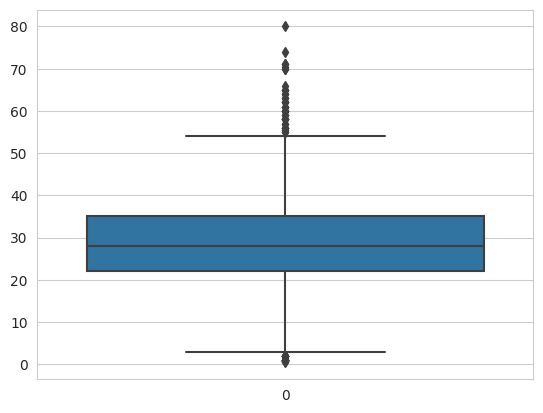

In [10]:
# visualize Outliers
sns.boxplot(df["Age"])
plt.show

STEP 3: Univariate Analysis

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

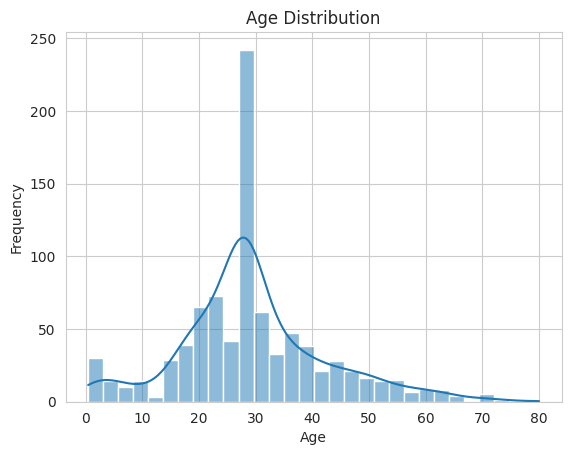

In [11]:
#Age Distribution of Passengers
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show

The distribution is mesokurtic.
The age diistribution has a positive skew where mean>median>mode

Text(0, 0.5, 'No. of Passengers')

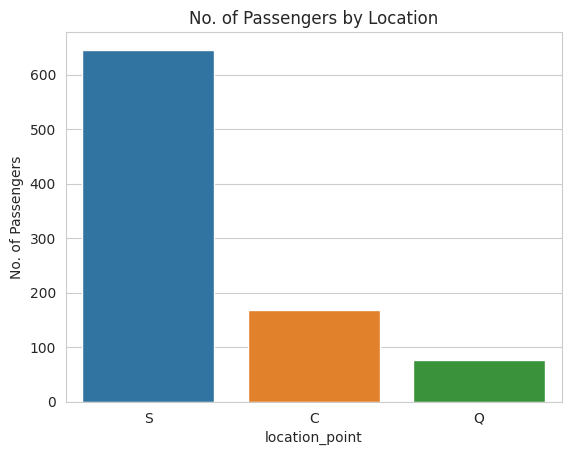

In [12]:
#Number of Passengers From Each Location.
df["Embarked"].value_counts(dropna=False)
sns.countplot(x=df["Embarked"])
plt.title("No. of Passengers by Location")
plt.xlabel("location_point")
plt.ylabel("No. of Passengers")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

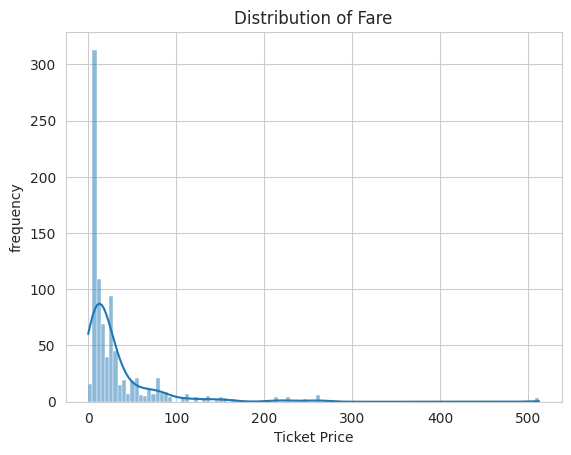

In [13]:
#Distribution of ticket prices
sns.histplot(df["Fare"], kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Ticket Price")
plt.ylabel("frequency")
plt.show

The distribution is a Mesocurtic distribution with a Positive Skew

STEP 4: BIVARIATE ANALYSIS

<function matplotlib.pyplot.show(close=None, block=None)>

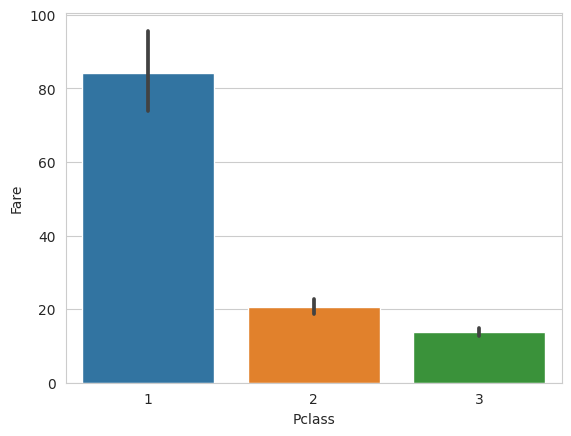

In [14]:
#does fare change depending on pclass?
sns.barplot(x="Pclass", y="Fare", data=df)
plt.show

INTERPRETATION: 
* First class paid higher fare amount
* Third class paid lowest amouts of fare 

<function matplotlib.pyplot.show(close=None, block=None)>

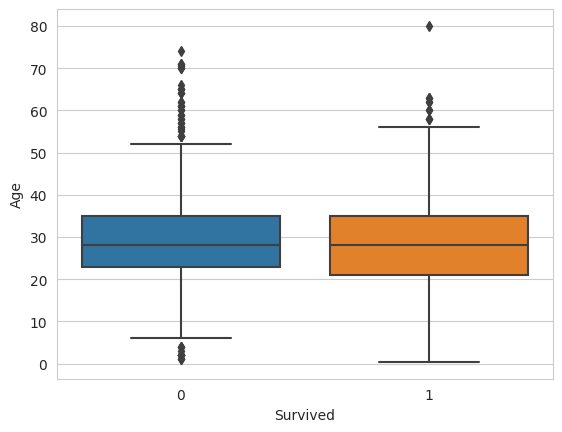

In [15]:
#are younger passengers more likely to survive titanic?
sns.boxplot(x="Survived", y="Age", data=df)
plt.show

INTERPRETATION: 
* Younger people had high survival chances
* Older people had less survival chances* 


<function matplotlib.pyplot.show(close=None, block=None)>

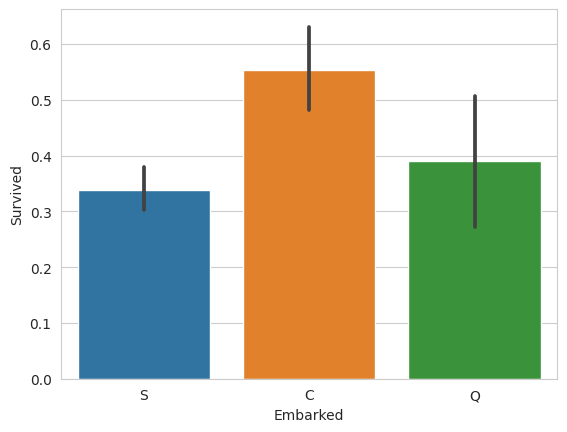

In [16]:
#Does the Embarked location affect survival rate?
sns.barplot(x="Embarked", y="Survived", data=df)
plt.show

INTERPRETATION: 
* Passengers from Cherbourg (C) survived more
* Passengers from Southampton (S) had lower survival

STEP 3: MULTIVARIATE ANALYSIS

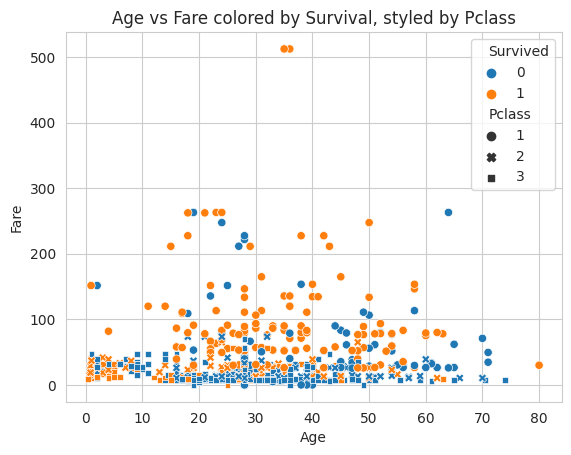

In [17]:
#How do Pclass, Age, and Fare jointly affect survival?
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', style='Pclass')
plt.title("Age vs Fare colored by Survival, styled by Pclass")
plt.show()

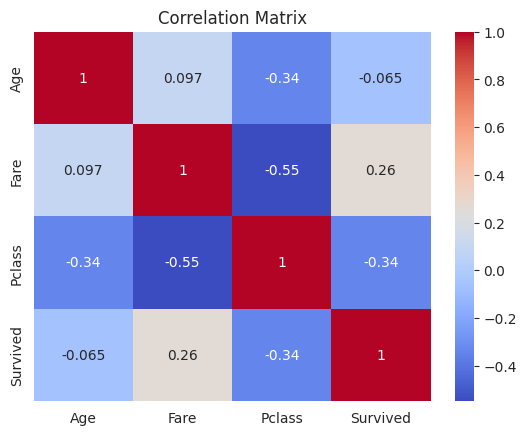

In [18]:
#Correlation 
corr_matrix = df[['Age', 'Fare', 'Pclass', 'Survived']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [22]:
survival_table = df.pivot_table(
    values="Survived",
    index="Pclass",
    columns="Embarked",
    aggfunc="mean"
)

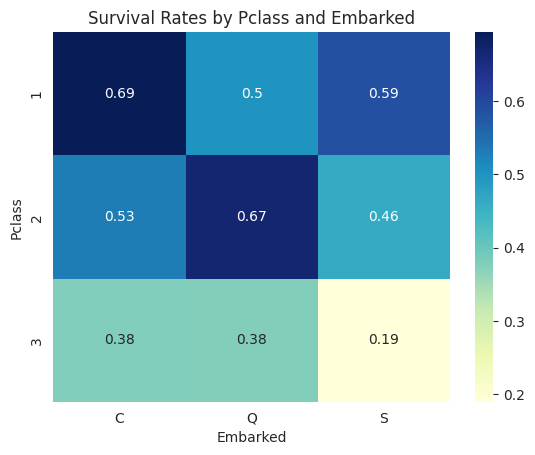

In [23]:
#Are survival rates different for Embarked locations when considering Pclass?
sns.heatmap(survival_table, annot=True, cmap="YlGnBu")
plt.title("Survival Rates by Pclass and Embarked")
plt.ylabel("Pclass")
plt.xlabel("Embarked")
plt.show()